# CLUSTERING

## 1. Objetivos

1. Identificar grupos de productos con comportamiento similar
2. Identificar comportamientos similares entre las tiendas


## 2. Importacion de librerias

In [7]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import sklearn
from sklearn import set_config

set_config(transform_output="pandas")

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin


In [8]:
print("Working with this sklearn version {}".format(sklearn.__version__))

Working with this sklearn version 1.8.0


## 3. Importación de datos

In [9]:
df = pd.read_parquet(r"data\dsMarket.parquet")

## 4. Feature Engineering

In [10]:
df.head()

,id,item,category,department,store,store_code,region,day,sales,date,start_date,yearweek,event,is_Ramadan,sell_price,store_id,is_Event,revenue
0,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_897,0,2013-07-13,2013-07-13,201328,NoEvent,True,12.7414,BOS_1_ACCESORIES_1,False,0.0000
1,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_898,0,2013-07-14,2013-07-13,201328,NoEvent,True,12.7414,BOS_1_ACCESORIES_1,False,0.0000
2,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_899,0,2013-07-15,2013-07-13,201328,NoEvent,True,12.7414,BOS_1_ACCESORIES_1,False,0.0000
3,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_900,1,2013-07-16,2013-07-13,201328,NoEvent,True,12.7414,BOS_1_ACCESORIES_1,False,12.7414
4,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_901,3,2013-07-17,2013-07-13,201328,NoEvent,True,12.7414,BOS_1_ACCESORIES_1,False,38.2242


In [11]:
df["event"].value_counts    ()

event
NoEvent             45149025
SuperBowl             138440
Easter                130145
NewYear               124653
Christmas             124368
Thanksgiving          123642
Ramadan starts        119150
Independence Day      118534
Name: count, dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46027957 entries, 0 to 46027956
Data columns (total 18 columns):
 #   Column      Dtype         
---  ------      -----         
 0   id          category      
 1   item        object        
 2   category    category      
 3   department  category      
 4   store       category      
 5   store_code  object        
 6   region      category      
 7   day         object        
 8   sales       int64         
 9   date        datetime64[ns]
 10  start_date  datetime64[ns]
 11  yearweek    int64         
 12  event       object        
 13  is_Ramadan  bool          
 14  sell_price  float64       
 15  store_id    object        
 16  is_Event    bool          
 17  revenue     float64       
dtypes: bool(2), category(5), datetime64[ns](2), float64(2), int64(2), object(5)
memory usage: 4.1+ GB


In [13]:
df["date"].describe()

count                         46027957
mean     2014-01-15 15:38:43.793640960
min                2011-01-29 00:00:00
25%                2012-11-23 00:00:00
50%                2014-03-10 00:00:00
75%                2015-04-12 00:00:00
max                2016-04-24 00:00:00
Name: date, dtype: object

In [14]:

# 1. TRANSFORMADOR DE ESTACIONES (Exactitud astronómica)
class SeasonExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, date_column='date'):
        self.date_column = date_column
        
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        X_out = X.copy()
        fechas = pd.to_datetime(X_out[self.date_column])
        mmdd = fechas.dt.month * 100 + fechas.dt.day
        
        # Definición de cortes para las estaciones
        bins = [0, 319, 620, 921, 1220, 1300]
        labels = ['Winter', 'Spring', 'Summer', 'Autumn', 'Winter_end']
        
        X_out['season'] = pd.cut(mmdd, bins=bins, labels=labels).replace('Winter_end', 'Winter')
        return X_out

# 2. TRANSFORMADOR DE EVENTOS (Globales + Locales + Maratones)
class EventTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, date_col='date', region_col='region', event_col='event'):
        self.date_col = date_col
        self.region_col = region_col
        self.event_col = event_col

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()
        fechas = pd.to_datetime(X_out[self.date_col])
        mes = fechas.dt.month
        dia = fechas.dt.day
        dia_semana = fechas.dt.dayofweek # 0=Lunes, 6=Domingo
        
        # Inicializamos la columna de eventos locales
        X_out['local_event_name'] = 'NoEvent'
        
        # --- LÓGICA DE EVENTOS LOCALES ---
        
        # Boston: Patriots' Day & Marathon (3er lunes de Abril: días entre 15-21 y que sea lunes)
        mask_boston = (X_out[self.region_col] == 'Boston') & (mes == 4) & (dia.between(15, 21)) & (dia_semana == 0)
        X_out.loc[mask_boston, 'local_event_name'] = 'Boston_Marathon_Patriots_Day'
        
        # NY: Marathon (1er domingo de Noviembre: días entre 1-7 y que sea domingo)
        mask_ny_marathon = (X_out[self.region_col] == 'New York') & (mes == 11) & (dia.between(1, 7)) & (dia_semana == 6)
        X_out.loc[mask_ny_marathon, 'local_event_name'] = 'NY_Marathon'

        # Philly: Broad Street Run (1er domingo de Mayo)
        mask_philly_run = (X_out[self.region_col] == 'Philadelphia') & (mes == 5) & (dia.between(1, 7)) & (dia_semana == 6)
        X_out.loc[mask_philly_run, 'local_event_name'] = 'Broad_Street_Run'

        # NY: St. Patrick's Day (17 de Marzo)
        mask_ny_stpat = (X_out[self.region_col] == 'New York') & (mes == 3) & (dia == 17)
        X_out.loc[mask_ny_stpat, 'local_event_name'] = 'St_Patricks_Day'

        # Philly: Mummers Parade (1 de Enero)
        mask_philly_mummers = (X_out[self.region_col] == 'Philadelphia') & (mes == 1) & (dia == 1)
        X_out.loc[mask_philly_mummers, 'local_event_name'] = 'Mummers_Parade'

        # --- CONSOLIDACIÓN ---
        
        # Creamos 'final_event': prioriza el evento global, si no hay, pone el local.
        X_out['final_event'] = np.where(X_out[self.event_col] != 'NoEvent', 
                                        X_out[self.event_col], 
                                        X_out['local_event_name'])
        
        # Variable binaria útil para clustering (¿Hay algún evento hoy?)
        X_out['is_event_day'] = (X_out['final_event'] != 'NoEvent').astype(int)

        # Limpiamos columnas auxiliares
        X_out = X_out.drop(columns=['local_event_name'])
        
        return X_out
# 3. TRANSFORMADOR DE DÍAS DE PAGO (Payday)
class PaydayTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, date_col='date'):
        self.date_col = date_col

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()
        dias = pd.to_datetime(X_out[self.date_col]).dt.day
        
        # En EE.UU. se suele cobrar el 1 y el 15. 
        # Añadimos el 2 y el 16 para capturar el pico de consumo inmediato y posibles retrasos por fin de semana.
        X_out['is_payday'] = dias.isin([1, 2, 15, 16]).astype(int)
        
        return X_out
# 4. TRANSFORMADOR DE DESCUENTOS REALES     
class DiscountTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, id_col='id', date_col='date', price_col='sell_price', window_days=28, threshold=0.05):
        # window_days=28 equivale a 4 semanas exactas (evita ruidos de qué día cae el mes)
        # threshold=0.05 es un 5% de descuento mínimo para considerarlo oferta
        self.id_col = id_col
        self.date_col = date_col
        self.price_col = price_col
        self.window_days = window_days
        self.threshold = threshold

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()
        
        # 1. ORDENAR LOS DATOS (Crítico para funciones móviles en series temporales)
        # Si no ordenamos por producto y luego por fecha, el rolling() mezclará el pasado con el futuro
        X_out = X_out.sort_values([self.id_col, self.date_col])
        
        # 2. Calcular el Precio Promedio Reciente (Rolling Average)
        # min_periods=1 asegura que los primeros días del dataset de un producto no den error (NaN)
        precio_promedio_reciente = X_out.groupby(self.id_col)[self.price_col].transform(
            lambda x: x.rolling(window=self.window_days, min_periods=1).mean()
        )
        
        # 3. Identificar la oferta real
        # ¿El precio de hoy es un X% más barato que el promedio de las últimas 4 semanas?
        limite_oferta = precio_promedio_reciente * (1 - self.threshold)
        X_out['is_discounted'] = (X_out[self.price_col] < limite_oferta).astype(int)
        
        # Devolvemos el dataset a su índice original por si acaso (opcional pero limpio)
        X_out = X_out.sort_index()
        
        return X_out

# 5. TRANSFORMADOR DE DÍAS DE PREVIOS A EVENTO
class EventLeadUpTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, store_col='store_id', date_col='date', event_col='is_event_day', lead_days=3):
        # lead_days=3 significa que marcaremos como "víspera" los 3 días anteriores a cualquier evento
        self.store_col = store_col
        self.date_col = date_col
        self.event_col = event_col
        self.lead_days = lead_days

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()
        
        # 1. Ordenamos por tienda y fecha (Vital para no mezclar eventos del futuro de otra tienda)
        X_out = X_out.sort_values([self.store_col, self.date_col])
        
        # Array inicial de ceros
        lead_up_series = np.zeros(len(X_out), dtype=int)
        
        # 2. Miramos hacia el futuro 'lead_days' días
        # Si hoy es lunes y el evento es el jueves (3 días), marcamos lunes, martes y miércoles.
        for i in range(1, self.lead_days + 1):
            # shift(-i) "sube" las filas, trayendo el futuro al presente.
            # fillna(0) evita errores en los últimos días del dataset.
            shifted = X_out.groupby(self.store_col)[self.event_col].shift(-i).fillna(0).astype(int)
            
            # Usamos el operador lógico OR (|) para combinar todos los días previos
            lead_up_series = lead_up_series | shifted
            
        # 3. Asignamos la nueva variable y restauramos el orden original
        X_out['is_event_leadup'] = lead_up_series
        X_out = X_out.sort_index()
        
        return X_out

## PIPELINE


In [15]:

feature_engineering_pipeline = Pipeline([
    ('season_extractor', SeasonExtractor(date_column='date')),
    #('events', EventTransformer(region_col='region', event_col='event')),
    #("payday", PaydayTransformer(date_col='date')),
    ('discounts', DiscountTransformer(id_col='id', date_col='date', price_col='sell_price')),
    #('event_leadup', EventLeadUpTransformer(store_col='store_id', date_col='date', event_col='is_event_day'))
])


In [16]:
df2 = df.copy()

In [17]:
# 1. Eliminamos columnas redundantes o inútiles para el clustering
# (Ajusta la lista si necesitas conservar alguna por algún motivo del profesor)
columnas_sobrantes = ['day', 'store', 'store_code', 'yearweek']
df_opt = df2.drop(columns=[col for col in columnas_sobrantes if col in df2.columns])

# 2. Conversión de Objects a Categorías (Ahorro masivo de RAM)
columnas_categoricas = ['item', 'event', 'store_id']
for col in columnas_categoricas:
    if col in df_opt.columns:
        df_opt[col] = df_opt[col].astype('category')

# 3. Downcasting de números enteros (de 64 a 32 bits)
# int32 soporta números hasta 2.147.483.647 (más que suficiente para ventas)
columnas_enteras = df_opt.select_dtypes(include=['int64']).columns
for col in columnas_enteras:
    df_opt[col] = df_opt[col].astype('int32')

# 4. Downcasting de decimales (de 64 a 32 bits)
columnas_float = df_opt.select_dtypes(include=['float64']).columns
for col in columnas_float:
    df_opt[col] = df_opt[col].astype('float32')

# Imprimimos el resultado de la dieta
print("--- ANTES ---")
df2.info(memory_usage='deep')
print("\n--- DESPUÉS ---")
df_opt.info(memory_usage='deep')

--- ANTES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46027957 entries, 0 to 46027956
Data columns (total 18 columns):
 #   Column      Dtype         
---  ------      -----         
 0   id          category      
 1   item        object        
 2   category    category      
 3   department  category      
 4   store       category      
 5   store_code  object        
 6   region      category      
 7   day         object        
 8   sales       int64         
 9   date        datetime64[ns]
 10  start_date  datetime64[ns]
 11  yearweek    int64         
 12  event       object        
 13  is_Ramadan  bool          
 14  sell_price  float64       
 15  store_id    object        
 16  is_Event    bool          
 17  revenue     float64       
dtypes: bool(2), category(5), datetime64[ns](2), float64(2), int64(2), object(5)
memory usage: 15.2 GB

--- DESPUÉS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46027957 entries, 0 to 46027956
Data columns (total 14 column

In [ ]:
df_procesado = feature_engineering_pipeline.fit_transform(df_opt)

In [19]:
df_procesado.head()

,id,item,category,department,region,sales,date,start_date,event,is_Ramadan,sell_price,store_id,is_Event,revenue,season,is_discounted
0,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Boston,0,2013-07-13,2013-07-13,NoEvent,True,12.7414,BOS_1_ACCESORIES_1,False,0.000000,Summer,0
1,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Boston,0,2013-07-14,2013-07-13,NoEvent,True,12.7414,BOS_1_ACCESORIES_1,False,0.000000,Summer,0
2,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Boston,0,2013-07-15,2013-07-13,NoEvent,True,12.7414,BOS_1_ACCESORIES_1,False,0.000000,Summer,0
3,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Boston,1,2013-07-16,2013-07-13,NoEvent,True,12.7414,BOS_1_ACCESORIES_1,False,12.741400,Summer,0
4,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Boston,3,2013-07-17,2013-07-13,NoEvent,True,12.7414,BOS_1_ACCESORIES_1,False,38.224201,Summer,0


## AGREGACIÓN DE LOS DATOS.

In [20]:

# 👉 1. Actualizamos las columnas. Quitamos las de eventos/cobros e incluimos is_Ramadan
columnas_necesarias = [
    'date', 'item', 'sales', 'revenue', 'sell_price', 'region', 
    'store_id', 'is_discounted', 'season',
]

class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X[self.columns].copy()

class ProductProfiler(BaseEstimator, TransformerMixin):
    def __init__(self, groupby_col='item'):
        self.groupby_col = groupby_col

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()
        # Si 'date' ya es datetime por el paso de optimización, esto no hace daño
        X_out['date'] = pd.to_datetime(X_out['date']) 
        
        # Identificar inicio de vida del producto
        first_sales = X_out[X_out['sales'] > 0].groupby(self.groupby_col)['date'].min().reset_index()
        first_sales.columns = [self.groupby_col, 'first_sale_date']
        X_out = X_out.merge(first_sales, on=self.groupby_col, how='left')
        
        # Filtrar vida activa
        X_active = X_out[X_out['date'] >= X_out['first_sale_date']].copy()
        
        # 👉 2. Auxiliares de ventas (Solo dejamos ofertas y añadimos Ramadán)
        X_active['sales_discount'] = X_active['sales'] * X_active['is_discounted']
        
        seasons = pd.get_dummies(X_active['season'], prefix='sales')
        for col in seasons.columns:
            X_active[col] = X_active['sales'] * seasons[col]

        # 👉 3. Agregación (Limpiamos basura y sumamos Ramadán)
        grouped = X_active.groupby(self.groupby_col).agg(
            total_sales=('sales', 'sum'),
            avg_sales_daily=('sales', 'mean'),
            std_sales=('sales', 'std'),        
            avg_price=('sell_price', 'mean'),
            max_price=('sell_price', 'max'),   
            min_price=('sell_price', 'min'),   
            real_life_days=('date', 'count'), 
            days_with_sales=('sales', lambda x: (x > 0).sum()),
            sum_s_discount=('sales_discount', 'sum'),
            sum_s_winter=('sales_Winter', 'sum'),
            sum_s_spring=('sales_Spring', 'sum'),
            sum_s_summer=('sales_Summer', 'sum'),
            sum_s_autumn=('sales_Autumn', 'sum')
        )

        eps = 1e-8
        
        # 👉 4. Cálculo de métricas finales (Las 9 dimensiones maestras)
        res = pd.DataFrame(index=grouped.index)
        res['volumen_total'] = np.log1p(grouped['total_sales']) 
        res['precio_medio'] = grouped['avg_price']
        res['rango_descuento'] = (grouped['max_price'] - grouped['min_price']) / (grouped['max_price'] + eps)
        res['frecuencia_venta'] = grouped['days_with_sales'] / (grouped['real_life_days'] + eps)
        res['volatilidad'] = grouped['std_sales'] / (grouped['avg_sales_daily'] + eps)
        
        # Ratios de comportamiento
        sales = grouped['total_sales'] + eps
        res['p_oferta'] = grouped['sum_s_discount'] / sales
        res['p_invierno'] = grouped['sum_s_winter'] / sales
        res['p_verano'] = grouped['sum_s_summer'] / sales
        
        
        return res.fillna(0)

In [21]:
cluster_pipeline = Pipeline([
    ("Selector", ColumnSelector(columns=columnas_necesarias)),
    ("profiler", ProductProfiler(groupby_col = "item")),
    ("RobustScaler", RobustScaler()),

])

In [22]:
cluster_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Selector', ...), ('profiler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,columns,"['date', 'item', ...]"
,groupby_col,'item'
,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"
,"copy copy: bool, default=TrueIf `False`, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"unit_variance unit_variance: bool, default=FalseIf `True`, scale data so that normally distributed features have avariance of 1. In general, if the difference between the x-values of`q_max` and `q_min` for a standard normal distribution is greaterthan 1, the dataset will be scaled down. If less than 1, the datasetwill be scaled up... versionadded:: 0.24",False


In [23]:
df_agg = cluster_pipeline.fit_transform(df_procesado)

In [24]:
df_agg

,volumen_total,precio_medio,rango_descuento,frecuencia_venta,volatilidad,p_oferta,p_invierno,p_verano
item,,,,,,,,
ACCESORIES_1_001,-0.527040,1.499968,0.237839,-0.252930,0.103349,0.638307,0.237839,-0.256157
ACCESORIES_1_002,-0.394848,0.239109,0.277865,-0.496982,0.533448,-0.145279,-0.530044,0.354508
ACCESORIES_1_003,-1.180787,-0.052905,1.041945,-0.699063,1.037274,0.907981,0.789512,-0.463743
ACCESORIES_1_004,0.882304,0.393878,-0.403252,0.807139,-0.522099,-0.193339,0.025918,-0.209070
ACCESORIES_1_005,0.267323,-0.077068,0.314854,0.190097,-0.239634,2.026678,-0.425801,0.196606
...,...,...,...,...,...,...,...,...
SUPERMARKET_3_823,0.299225,-0.183749,0.656378,-0.148679,0.389419,4.444098,0.375768,-0.067155
SUPERMARKET_3_824,-0.084083,-0.253845,-0.257129,-0.334457,0.510908,0.536804,-1.114364,0.701800
SUPERMARKET_3_825,0.218750,0.164114,0.386944,0.038005,-0.050024,1.972717,0.503593,0.347810


## Clustering process

### Elbow curve

In [25]:
sse = {}

for k in range(2, 15):
    print(f"Fitting pipe with {k} clusters")
    clustering_model = KMeans(n_clusters=k)
    clustering_model.fit(df_agg)
    sse[k] = clustering_model.inertia_

Fitting pipe with 2 clusters
Fitting pipe with 3 clusters
Fitting pipe with 4 clusters
Fitting pipe with 5 clusters
Fitting pipe with 6 clusters
Fitting pipe with 7 clusters
Fitting pipe with 8 clusters
Fitting pipe with 9 clusters
Fitting pipe with 10 clusters
Fitting pipe with 11 clusters
Fitting pipe with 12 clusters
Fitting pipe with 13 clusters
Fitting pipe with 14 clusters


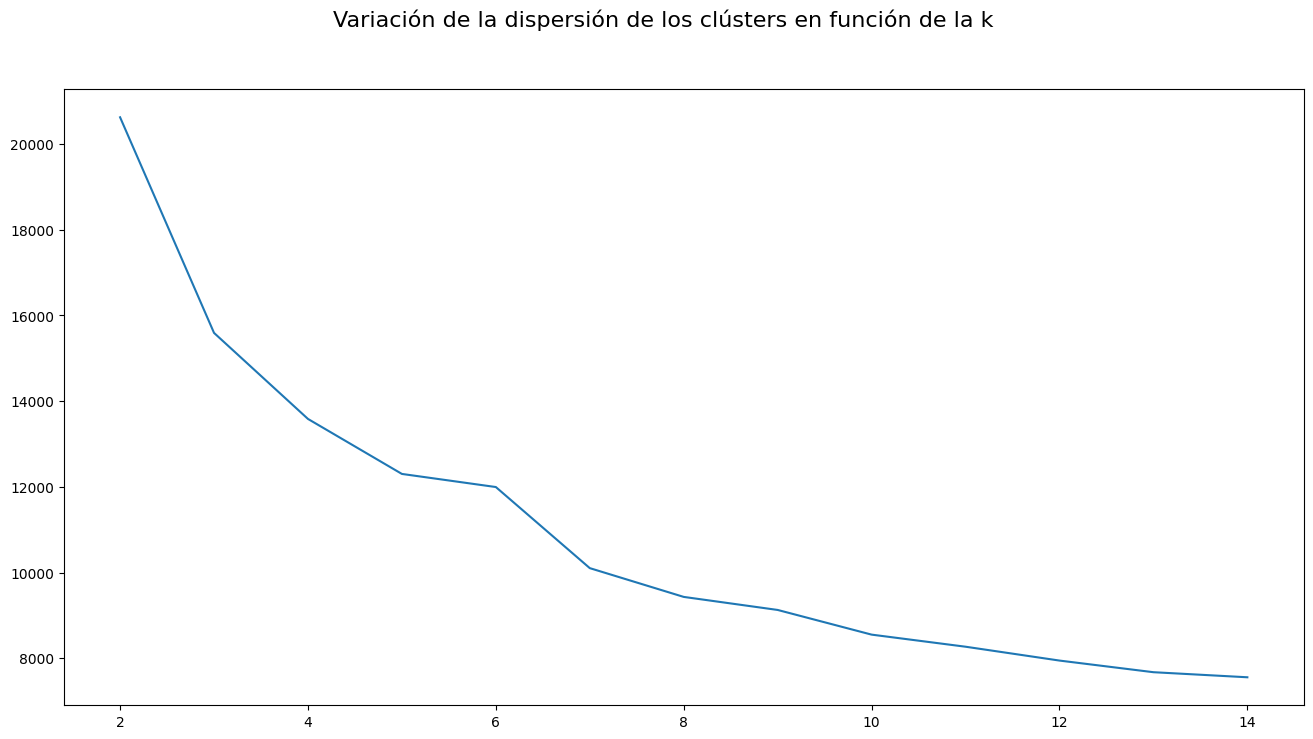

In [26]:
fig = plt.figure(figsize=(16,8))
ax = fig.add_subplot()

x_values = list(sse.keys())
y_values = list(sse.values())

ax.plot(x_values, y_values, label = "Inertia/dispersión de los clústers")
fig.suptitle(
    "Variación de la dispersión de los clústers en función de la k", fontsize = 16
);

### Segmentación de los productos con la "k adecuada"

In [27]:
cluster_pipeline = Pipeline([
    ("Selector", ColumnSelector(columns=columnas_necesarias)),
    ("profiler", ProductProfiler(groupby_col = "item")),
    ("RobustScaler", RobustScaler()),
    ("Clustering", KMeans(n_clusters=6, random_state=42)),

])

In [28]:
cluster_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Selector', ...), ('profiler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,columns,"['date', 'item', ...]"
,groupby_col,'item'
,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"
,"copy copy: bool, default=TrueIf `False`, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"unit_variance unit_variance: bool, default=FalseIf `True`, scale data so that normally distributed features have avariance of 1. In general, if the difference between the x-values of`q_max` and `q_min` for a standard normal distribution is greaterthan 1, the dataset will be scaled down. If less than 1, the datasetwill be scaled up... versionadded:: 0.24",False


In [29]:
cluster_pipeline.fit(df_procesado)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Selector', ...), ('profiler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,columns,"['date', 'item', ...]"
,groupby_col,'item'
,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"
,"copy copy: bool, default=TrueIf `False`, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"unit_variance unit_variance: bool, default=FalseIf `True`, scale data so that normally distributed features have avariance of 1. In general, if the difference between the x-values of`q_max` and `q_min` for a standard normal distribution is greaterthan 1, the dataset will be scaled down. If less than 1, the datasetwill be scaled up... versionadded:: 0.24",False


In [30]:
X_procesado = cluster_pipeline[:3].transform(df_procesado)

In [31]:
X_procesado

,volumen_total,precio_medio,rango_descuento,frecuencia_venta,volatilidad,p_oferta,p_invierno,p_verano
item,,,,,,,,
ACCESORIES_1_001,-0.527040,1.499968,0.237839,-0.252930,0.103349,0.638307,0.237839,-0.256157
ACCESORIES_1_002,-0.394848,0.239109,0.277865,-0.496982,0.533448,-0.145279,-0.530044,0.354508
ACCESORIES_1_003,-1.180787,-0.052905,1.041945,-0.699063,1.037274,0.907981,0.789512,-0.463743
ACCESORIES_1_004,0.882304,0.393878,-0.403252,0.807139,-0.522099,-0.193339,0.025918,-0.209070
ACCESORIES_1_005,0.267323,-0.077068,0.314854,0.190097,-0.239634,2.026678,-0.425801,0.196606
...,...,...,...,...,...,...,...,...
SUPERMARKET_3_823,0.299225,-0.183749,0.656378,-0.148679,0.389419,4.444098,0.375768,-0.067155
SUPERMARKET_3_824,-0.084083,-0.253845,-0.257129,-0.334457,0.510908,0.536804,-1.114364,0.701800
SUPERMARKET_3_825,0.218750,0.164114,0.386944,0.038005,-0.050024,1.972717,0.503593,0.347810


In [32]:
labels = cluster_pipeline["Clustering"].labels_

In [33]:
labels

array([0, 5, 2, ..., 1, 3, 2], shape=(3049,), dtype=int32)

In [34]:
df_cluster = cluster_pipeline[:2].transform(df_procesado)

NotFittedError: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
df_cluster["cluster"] = labels

In [ ]:
df_cluster

,volumen_total,precio_medio,rango_descuento,frecuencia_venta,volatilidad,p_oferta,p_invierno,p_verano,cluster
item,,,,,,,,,
ACCESORIES_1_001,8.317278,11.030711,0.478079,0.291840,1.828604,0.006841,0.272416,0.231126,0
ACCESORIES_1_002,8.529122,5.276608,0.496222,0.215492,2.195801,0.000395,0.238387,0.259142,5
ACCESORIES_1_003,7.269617,3.943964,0.842546,0.152272,2.625941,0.009059,0.296864,0.221603,2
ACCESORIES_1_004,10.575820,5.982920,0.187500,0.623472,1.294629,0.000000,0.263025,0.233287,3
ACCESORIES_1_005,9.590283,3.833692,0.512987,0.430437,1.535783,0.018261,0.243007,0.251898,1
...,...,...,...,...,...,...,...,...,...
SUPERMARKET_3_823,9.641408,3.346839,0.667785,0.324454,2.072836,0.038147,0.278529,0.239797,1
SUPERMARKET_3_824,9.027138,3.026945,0.253731,0.266336,2.176557,0.006006,0.212492,0.275075,5
SUPERMARKET_3_825,9.512443,4.934360,0.545662,0.382856,1.697662,0.017818,0.284193,0.258835,1


### FICHA DE PRODUCTOS

In [ ]:

# 1. Definimos las NUEVAS 9 columnas de nuestro modelo final
columnas_analisis = [
    "volumen_total", "precio_medio", "rango_descuento", 
    "frecuencia_venta", "volatilidad", 
    "p_oferta", 
    "p_invierno", "p_verano"
]

# 2. Generamos la base de la ficha (estadísticos por cluster)
ficha_df = pd.DataFrame()

for col in columnas_analisis:
    # describe().T[1:] extrae: mean, std, min, 25%, 50%, 75%, max
    resumen_data = df_cluster[["cluster", col]].groupby("cluster").describe().T[1:]
    ficha_df = pd.concat([ficha_df, resumen_data])

# 3. Creamos la estructura del MultiIndex adaptada
# Ajustamos los grupos estratégicos al nuevo modelo
out_index = [
    "Ventas", "Ventas", "Ventas",            # volumen_total, precio_medio, rango_descuento
    "Hábito", "Hábito",                      # frecuencia_venta, volatilidad
    "Promociones",                           # p_oferta
    "Estacionalidad", "Estacionalidad"      # p_invierno, p_verano
    
]

inner_index = [
    "Volumen Total (log)", "Precio Medio", "Rango de Descuento",
    "Frecuencia de Venta", "Volatilidad de Venta",
    "Sensibilidad Oferta",
    "Ventas Invierno", "Ventas Verano"
    
]

estadisticos = ["Media", "Desviación", "Mínimo", "Perc. 25", "Perc. 50", "Perc. 75", "Máximo"]

# Construcción de la lista de tuplas para el MultiIndex
new_multi_index = []
for oi, ii in zip(out_index, inner_index):
    for es in estadisticos:
        new_multi_index.append((oi, ii, es))

# Función para generar el MultiIndex
def generate_multiindex(list_of_tuples, names):
    return pd.MultiIndex.from_tuples(list_of_tuples, names=names)

names = ["Grupo Indicadores", "Indicador", "Estadístico"]
index_ficha = generate_multiindex(new_multi_index, names)
ficha_df.set_index(index_ficha, inplace=True)

# 4. Añadimos el Tamaño de cada Cluster al principio
tamaño_clusters = df_cluster.groupby("cluster").size().to_frame().T
tamaño_clusters.set_index(
    generate_multiindex([("General", "Clúster", "Tamaño")], names), inplace=True
)

ficha_df = pd.concat([tamaño_clusters, ficha_df])

# 5. Formato final y gradiente de color
float_format = "{:.2f}"
ficha_final_styled = (
    ficha_df
    .style
    .format(float_format)
    .background_gradient(cmap="Blues", axis=1)
)

display(ficha_final_styled)

In [ ]:
import plotly.graph_objects as go
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Recuperamos los nombres comerciales
nombres_clusters = {
    0: "Long Tail (Nicho)",
    1: "Premium (Volátiles)",
    2: "Especialistas Invierno",
    3: "Pilares de la Tienda",
    4: "Cazadores de Gangas",
    5: "Especialistas Verano"
}

# 2. Preparamos los datos: Necesitamos las MEDIAS de cada variable por cluster
# Supongo que tu dataframe agrupado y con la columna 'cluster' se llama df_cluster
resumen_medias = df_cluster.groupby('cluster')[columnas_analisis].mean()
resumen_medias.rename(index=nombres_clusters, inplace=True)

# 3. Escalamos los datos de 0 a 1 SOLO para el gráfico 
# (Para que el Precio en dólares y la Frecuencia en % quepan en la misma escala visual)
scaler_radar = MinMaxScaler()
resumen_escalado = pd.DataFrame(
    scaler_radar.fit_transform(resumen_medias), 
    columns=resumen_medias.columns, 
    index=resumen_medias.index
)

# 4. Generamos el Gráfico de Radar
variables = resumen_escalado.columns.tolist()
variables += [variables[0]] # Cerramos el polígono repitiendo el primer valor

fig = go.Figure()

colores = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4']

for i, (nombre_cluster, fila) in enumerate(resumen_escalado.iterrows()):
    valores = fila.tolist()
    valores += [valores[0]] # Cerramos el polígono
    
    fig.add_trace(go.Scatterpolar(
        r=valores,
        theta=variables,
        fill='toself',
        name=nombre_cluster,
        line_color=colores[i],
        opacity=0.6
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[0, 1])
    ),
    showlegend=True,
    title="Perfil de los 6 Segmentos de Negocio (Escalado Min-Max)",
    width=800,
    height=600
)

fig.show()